## Mount to Google Drive

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Import Packages

In [3]:
!pip install ta

  Preparing metadata (setup.py) ... done
  Created wheel for ta: filename=ta-0.11.0-py3-none-any.whl size=29412 sha256=859c1d5b4b07462bc2c423ecc6b6f05c8675df0d13453c02e6ab323989d891af
  Stored in directory: /root/.cache/pip/wheels/a1/d7/29/7781cc5eb9a3659d032d7d15bdd0f49d07d2b24fec29f44bc4
Successfully built ta


In [4]:
!pip install keras-tuner

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 129.1/129.1 kB 2.5 MB/s eta 0:00:00


In [5]:
import os
import math
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
import ta
from ta.volatility import BollingerBands
from ta.trend import MACD, ADXIndicator
from ta.momentum import RSIIndicator


## Load datasets

In [6]:
# Load datasets
prices = pd.read_csv('/content/drive/MyDrive/Data set/prices.csv')
prices_split_adjusted = pd.read_csv('/content/drive/MyDrive/Data set/prices-split-adjusted.csv')
securities = pd.read_csv('/content/drive/MyDrive/Data set/securities.csv')
fundamentals = pd.read_csv('/content/drive/MyDrive/Data set/fundamentals.csv')

In [7]:
# Merge prices and prices_split_adjusted on 'symbol' and 'date'
merged_prices = pd.merge(prices, prices_split_adjusted, on=['symbol', 'date'], suffixes=('', '_adjusted'))

# Merge with securities on 'symbol' and 'Ticker symbol'
merged_data = pd.merge(merged_prices, securities, left_on='symbol', right_on='Ticker symbol')

# Merge with fundamentals on 'symbol' and 'Ticker symbol'
merged_data = pd.merge(merged_prices, fundamentals, left_on='symbol', right_on='Ticker Symbol')



# EDA

### 1. Display first few rows of each dataset

In [8]:
prices.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05 00:00:00,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06 00:00:00,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07 00:00:00,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08 00:00:00,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11 00:00:00,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [9]:
prices_split_adjusted.head()

,date,symbol,open,close,low,high,volume
0,2016-01-05,WLTW,123.430000,125.839996,122.309998,126.250000,2163600.0
1,2016-01-06,WLTW,125.239998,119.980003,119.940002,125.540001,2386400.0
2,2016-01-07,WLTW,116.379997,114.949997,114.930000,119.739998,2489500.0
3,2016-01-08,WLTW,115.480003,116.620003,113.500000,117.440002,2006300.0
4,2016-01-11,WLTW,117.010002,114.970001,114.089996,117.330002,1408600.0


In [10]:
securities.head()

,Ticker symbol,Security,SEC filings,GICS Sector,GICS Sub Industry,Address of Headquarters,Date first added,CIK
0,MMM,3M Company,reports,Industrials,Industrial Conglomerates,"St. Paul, Minnesota",NaN,66740
1,ABT,Abbott Laboratories,reports,Health Care,Health Care Equipment,"North Chicago, Illinois",1964-03-31,1800
2,ABBV,AbbVie,reports,Health Care,Pharmaceuticals,"North Chicago, Illinois",2012-12-31,1551152
3,ACN,Accenture plc,reports,Information Technology,IT Consulting & Other Services,"Dublin, Ireland",2011-07-06,1467373
4,ATVI,Activision Blizzard,reports,Information Technology,Home Entertainment Software,"Santa Monica, California",2015-08-31,718877


In [11]:
fundamentals.head()

,Unnamed: 0,Ticker Symbol,Period Ending,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
0,0,AAL,2012-12-31,3.068000e+09,-222000000.0,-1.961000e+09,23.0,-1.888000e+09,4.695000e+09,53.0,...,7.072000e+09,9.011000e+09,-7.987000e+09,2.489100e+10,1.690400e+10,2.485500e+10,-367000000.0,2012.0,-5.60,3.350000e+08
1,1,AAL,2013-12-31,4.975000e+09,-93000000.0,-2.723000e+09,67.0,-3.114000e+09,1.059200e+10,75.0,...,1.432300e+10,1.380600e+10,-2.731000e+09,4.500900e+10,4.227800e+10,2.674300e+10,0.0,2013.0,-11.25,1.630222e+08
2,2,AAL,2014-12-31,4.668000e+09,-160000000.0,-1.500000e+08,143.0,-5.311000e+09,1.513500e+10,60.0,...,1.175000e+10,1.340400e+10,2.021000e+09,4.120400e+10,4.322500e+10,4.265000e+10,0.0,2014.0,4.02,7.169154e+08
3,3,AAL,2015-12-31,5.102000e+09,352000000.0,-7.080000e+08,135.0,-6.151000e+09,1.159100e+10,51.0,...,9.985000e+09,1.360500e+10,5.635000e+09,4.278000e+10,4.841500e+10,4.099000e+10,0.0,2015.0,11.39,6.681299e+08
4,4,AAP,2012-12-29,2.409453e+09,-89482000.0,6.000000e+05,32.0,-2.711820e+08,5.202150e+08,23.0,...,3.184200e+09,2.559638e+09,1.210694e+09,3.403120e+09,4.613814e+09,6.205003e+09,-27095000.0,2012.0,5.29,7.328355e+07


### 2. Summary of the datasets

In [12]:
print("Price Dataset")
print(prices.info())

Price Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None


In [13]:
print("Prices_split_adjusted Dataset")
print(prices_split_adjusted.info())

Prices_split_adjusted Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 851264 entries, 0 to 851263
Data columns (total 7 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   date    851264 non-null  object 
 1   symbol  851264 non-null  object 
 2   open    851264 non-null  float64
 3   close   851264 non-null  float64
 4   low     851264 non-null  float64
 5   high    851264 non-null  float64
 6   volume  851264 non-null  float64
dtypes: float64(5), object(2)
memory usage: 45.5+ MB
None


In [14]:
print("Securities Dataset")
print(securities.info())

Securities Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 505 entries, 0 to 504
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   Ticker symbol            505 non-null    object
 1   Security                 505 non-null    object
 2   SEC filings              505 non-null    object
 3   GICS Sector              505 non-null    object
 4   GICS Sub Industry        505 non-null    object
 5   Address of Headquarters  505 non-null    object
 6   Date first added         307 non-null    object
 7   CIK                      505 non-null    int64 
dtypes: int64(1), object(7)
memory usage: 31.7+ KB
None


In [15]:
print("Fundamentals Dataset")
print(fundamentals.info())

Fundamentals Dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1781 entries, 0 to 1780
Data columns (total 79 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   Unnamed: 0                                           1781 non-null   int64  
 1   Ticker Symbol                                        1781 non-null   object 
 2   Period Ending                                        1781 non-null   object 
 3   Accounts Payable                                     1781 non-null   float64
 4   Accounts Receivable                                  1781 non-null   float64
 5   Add'l income/expense items                           1781 non-null   float64
 6   After Tax ROE                                        1781 non-null   float64
 7   Capital Expenditures                                 1781 non-null   float64
 8   Capital Surplus                                

### 3. Check for Missing Values

In [16]:
print("Price Dataset")
print(prices.isnull().sum())

Price Dataset
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64


In [17]:
print("Prices_split_adjusted Dataset")
print(prices_split_adjusted.isnull().sum())

Prices_split_adjusted Dataset
date      0
symbol    0
open      0
close     0
low       0
high      0
volume    0
dtype: int64


In [18]:
print("Securities Dataset")
print(securities.isnull().sum())

Securities Dataset
Ticker symbol                0
Security                     0
SEC filings                  0
GICS Sector                  0
GICS Sub Industry            0
Address of Headquarters      0
Date first added           198
CIK                          0
dtype: int64


In [19]:
# Print the dataset name
print("Fundamentals Dataset")

# Print column-wise null value counts
for column in fundamentals.columns:
    print(f"{column}: {fundamentals[column].isnull().sum()} records")

Fundamentals Dataset
Unnamed: 0: 0 records
Ticker Symbol: 0 records
Period Ending: 0 records
Accounts Payable: 0 records
Accounts Receivable: 0 records
Add'l income/expense items: 0 records
After Tax ROE: 0 records
Capital Expenditures: 0 records
Capital Surplus: 0 records
Cash Ratio: 299 records
Cash and Cash Equivalents: 0 records
Changes in Inventories: 0 records
Common Stocks: 0 records
Cost of Revenue: 0 records
Current Ratio: 299 records
Deferred Asset Charges: 0 records
Deferred Liability Charges: 0 records
Depreciation: 0 records
Earnings Before Interest and Tax: 0 records
Earnings Before Tax: 0 records
Effect of Exchange Rate: 0 records
Equity Earnings/Loss Unconsolidated Subsidiary: 0 records
Fixed Assets: 0 records
Goodwill: 0 records
Gross Margin: 0 records
Gross Profit: 0 records
Income Tax: 0 records
Intangible Assets: 0 records
Interest Expense: 0 records
Inventory: 0 records
Investments: 0 records
Liabilities: 0 records
Long-Term Debt: 0 records
Long-Term Investments: 0

### 4. Descriptive Statistics

In [20]:
print("Prices Dataset")
prices.describe()

Prices Dataset


,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,70.836986,70.857109,70.118414,71.543476,5.415113e+06
std,83.695876,83.689686,82.877294,84.465504,1.249468e+07
min,0.850000,0.860000,0.830000,0.880000,0.000000e+00
25%,33.840000,33.849998,33.480000,34.189999,1.221500e+06
50%,52.770000,52.799999,52.230000,53.310001,2.476250e+06
75%,79.879997,79.889999,79.110001,80.610001,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [21]:
print("Prices_split_adjusted Dataset")
prices_split_adjusted.describe()

Prices_split_adjusted Dataset


,open,close,low,high,volume
count,851264.000000,851264.000000,851264.000000,851264.000000,8.512640e+05
mean,64.993618,65.011913,64.336541,65.639748,5.415113e+06
std,75.203893,75.201216,74.459518,75.906861,1.249468e+07
min,1.660000,1.590000,1.500000,1.810000,0.000000e+00
25%,31.270000,31.292776,30.940001,31.620001,1.221500e+06
50%,48.459999,48.480000,47.970001,48.959999,2.476250e+06
75%,75.120003,75.139999,74.400002,75.849998,5.222500e+06
max,1584.439941,1578.130005,1549.939941,1600.930054,8.596434e+08


In [22]:
print("Securities Dataset")
securities.describe()

Securities Dataset


,CIK
count,5.050000e+02
mean,7.074490e+05
std,5.144375e+05
min,1.800000e+03
25%,8.631200e+04
50%,8.310010e+05
75%,1.075531e+06
max,1.659166e+06


In [23]:
print("Fundamentals Dataset")
fundamentals.describe()

Fundamentals Dataset


,Unnamed: 0,Accounts Payable,Accounts Receivable,Add'l income/expense items,After Tax ROE,Capital Expenditures,Capital Surplus,Cash Ratio,Cash and Cash Equivalents,Changes in Inventories,...,Total Current Assets,Total Current Liabilities,Total Equity,Total Liabilities,Total Liabilities & Equity,Total Revenue,Treasury Stock,For Year,Earnings Per Share,Estimated Shares Outstanding
count,1781.000000,1.781000e+03,1.781000e+03,1.781000e+03,1781.000000,1.781000e+03,1.781000e+03,1482.000000,1.781000e+03,1.781000e+03,...,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1.781000e+03,1608.000000,1562.000000,1.562000e+03
mean,890.000000,4.673418e+09,-6.353484e+07,6.908940e+07,43.601348,-1.251925e+09,5.351784e+09,74.457490,8.521399e+09,-6.787749e+07,...,6.726349e+09,4.699919e+09,1.188846e+10,4.380420e+10,5.569266e+10,2.029154e+10,-3.951522e+09,2013.305348,3.353707,6.024244e+08
std,514.274732,1.406047e+10,7.562794e+08,6.848143e+08,233.924028,2.979963e+09,1.133977e+10,102.298374,5.432105e+10,3.903369e+08,...,1.344800e+10,9.538832e+09,2.584429e+10,1.817039e+11,2.033612e+11,4.095355e+10,1.407047e+10,19.953135,4.695896,1.142585e+09
min,0.000000,0.000000e+00,-6.452000e+09,-6.768000e+09,0.000000,-3.798500e+10,-7.215000e+08,0.000000,2.100000e+04,-5.562000e+09,...,0.000000e+00,0.000000e+00,-1.324400e+10,2.577000e+06,2.705000e+06,1.514000e+06,-2.297340e+11,1215.000000,-61.200000,-1.513945e+09
25%,445.000000,5.160000e+08,-1.040000e+08,-2.638000e+06,10.000000,-1.151200e+09,4.791000e+08,17.000000,3.088000e+08,-5.400000e+07,...,1.044178e+09,5.640760e+08,2.201492e+09,3.843300e+09,6.552689e+09,3.714000e+09,-3.040895e+09,2013.000000,1.590000,1.493318e+08
50%,890.000000,1.334000e+09,-1.830000e+07,2.000000e+06,16.000000,-3.580000e+08,1.997080e+09,41.000000,8.625900e+08,0.000000e+00,...,2.747200e+09,1.701500e+09,4.983000e+09,9.141000e+09,1.517000e+10,8.023200e+09,-3.068350e+08,2014.000000,2.810000,2.929409e+08
75%,1335.000000,3.246000e+09,7.816000e+06,3.359200e+07,26.000000,-1.291000e+08,5.735000e+09,90.000000,2.310000e+09,0.000000e+00,...,6.162000e+09,4.381000e+09,1.080900e+10,2.389700e+10,3.599710e+10,1.748600e+10,0.000000e+00,2015.000000,4.590000,5.492163e+08
max,1780.000000,2.069390e+11,2.266400e+10,1.416200e+10,5789.000000,5.000000e+06,1.082880e+11,1041.000000,7.281110e+11,3.755000e+09,...,1.396600e+11,9.028100e+10,2.562050e+11,2.340547e+12,2.572274e+12,4.856510e+11,0.000000e+00,2016.000000,50.090000,1.610769e+10


In [24]:
# Assuming 'merged_data' from the provided code is available.
unique_symbols = merged_data['symbol'].unique()
unique_symbols

array(['AAL', 'AAP', 'AAPL', 'ABC', 'ABT', 'ADBE', 'ADI', 'ADM', 'ADS',
       'ADSK', 'AEE', 'AEP', 'AFL', 'AIG', 'AIZ', 'AJG', 'AKAM', 'ALB',
       'ALK', 'ALL', 'ALXN', 'AMAT', 'AME', 'AMG', 'AMGN', 'AMP', 'AMT',
       'AMZN', 'AN', 'ANTM', 'AON', 'APA', 'APC', 'APD', 'APH', 'ARNC',
       'ATVI', 'AVB', 'AVGO', 'AVY', 'AWK', 'AXP', 'AYI', 'AZO', 'BA',
       'BAC', 'BAX', 'BBBY', 'BBT', 'BBY', 'BCR', 'BDX', 'BHI', 'BIIB',
       'BK', 'BLL', 'BMY', 'BSX', 'BWA', 'BXP', 'C', 'CAG', 'CAH', 'CAT',
       'CB', 'CBG', 'CCI', 'CCL', 'CELG', 'CERN', 'CF', 'CHD', 'CHK',
       'CHRW', 'CI', 'CINF', 'CL', 'CLX', 'CMA', 'CME', 'CMG', 'CMI',
       'CMS', 'CNC', 'CNP', 'COF', 'COG', 'COL', 'COO', 'COST', 'CPB',
       'CRM', 'CSCO', 'CSX', 'CTAS', 'CTL', 'CTSH', 'CTXS', 'CVS', 'CVX',
       'CXO', 'D', 'DAL', 'DD', 'DE', 'DFS', 'DG', 'DGX', 'DHI', 'DHR',
       'DIS', 'DISCA', 'DISCK', 'DLR', 'DLTR', 'DNB', 'DOV', 'DPS', 'DRI',
       'DUK', 'DVA', 'DVN', 'EA', 'EBAY', 'ECL', 'ED', 'EFX', 

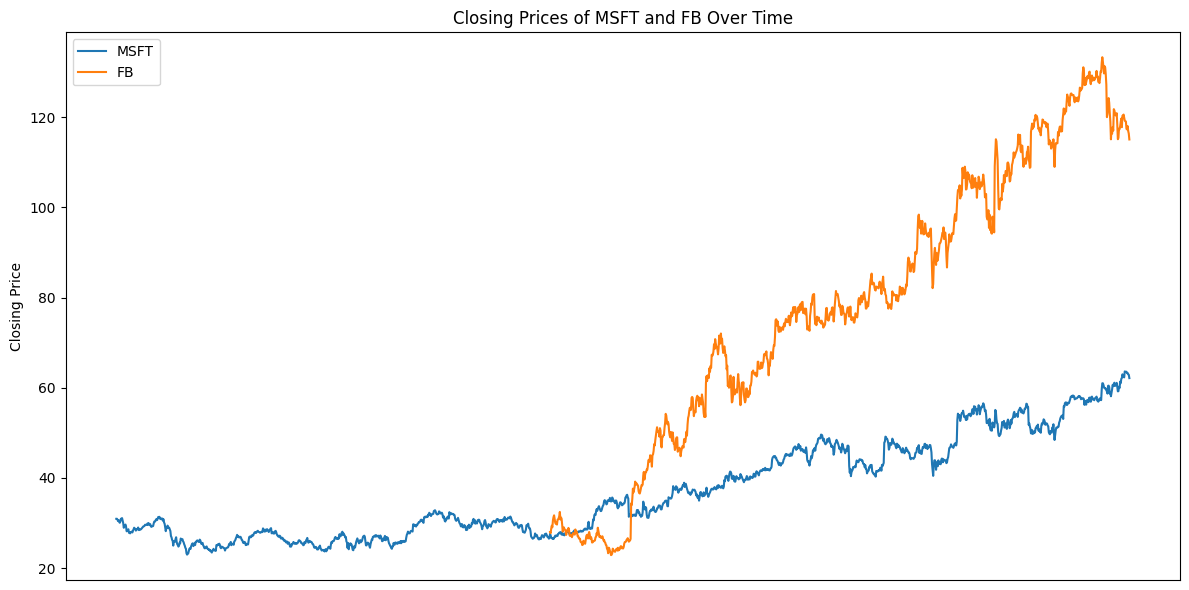

In [25]:
# Filter data for Microsoft (MSFT) and Facebook (FB)
msft_df = merged_data[merged_data['symbol'] == 'MSFT']
fb_df = merged_data[merged_data['symbol'] == 'FB']

# Combine the two DataFrames
msfb_df = pd.concat([msft_df, fb_df])

# Visualize 'close' data over time
plt.figure(figsize=(12, 6))
for symbol in ['MSFT', 'FB']:
    plt.plot(msfb_df[msfb_df['symbol'] == symbol]['date'], msfb_df[msfb_df['symbol'] == symbol]['close'], label=symbol)

plt.ylabel('Closing Price')
plt.title('Closing Prices of MSFT and FB Over Time')
plt.legend()

# Hide the x-axis
plt.gca().axes.get_xaxis().set_visible(False)

plt.tight_layout()
plt.show()

###  Distribution of sectors

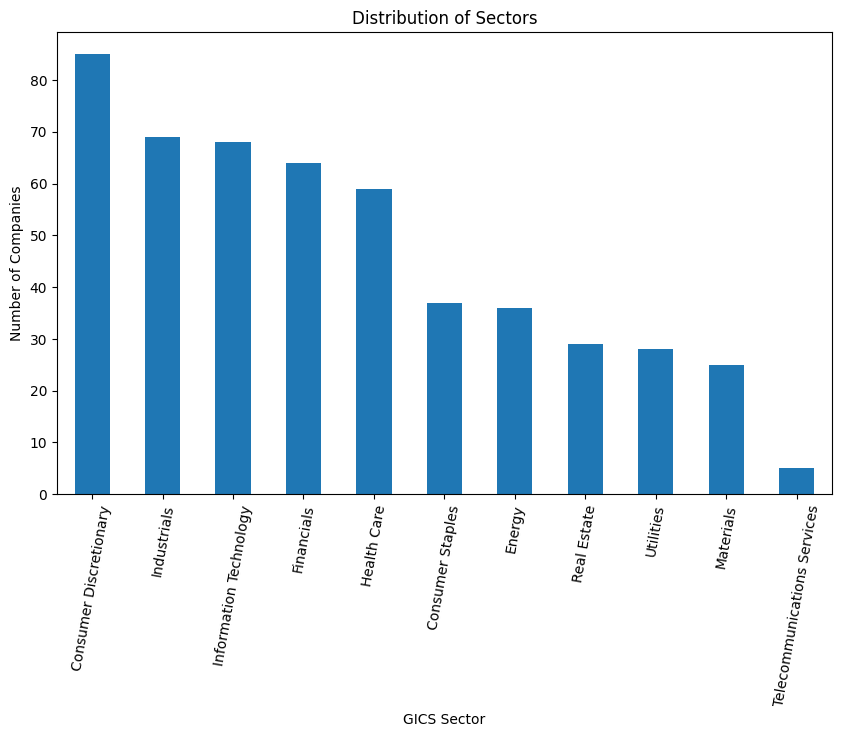

In [26]:
# Distribution of sectors
plt.figure(figsize=(10, 6))
securities['GICS Sector'].value_counts().plot(kind='bar')
plt.title('Distribution of Sectors')
plt.xlabel('GICS Sector')
plt.ylabel('Number of Companies')
plt.xticks(rotation=80)
plt.show()

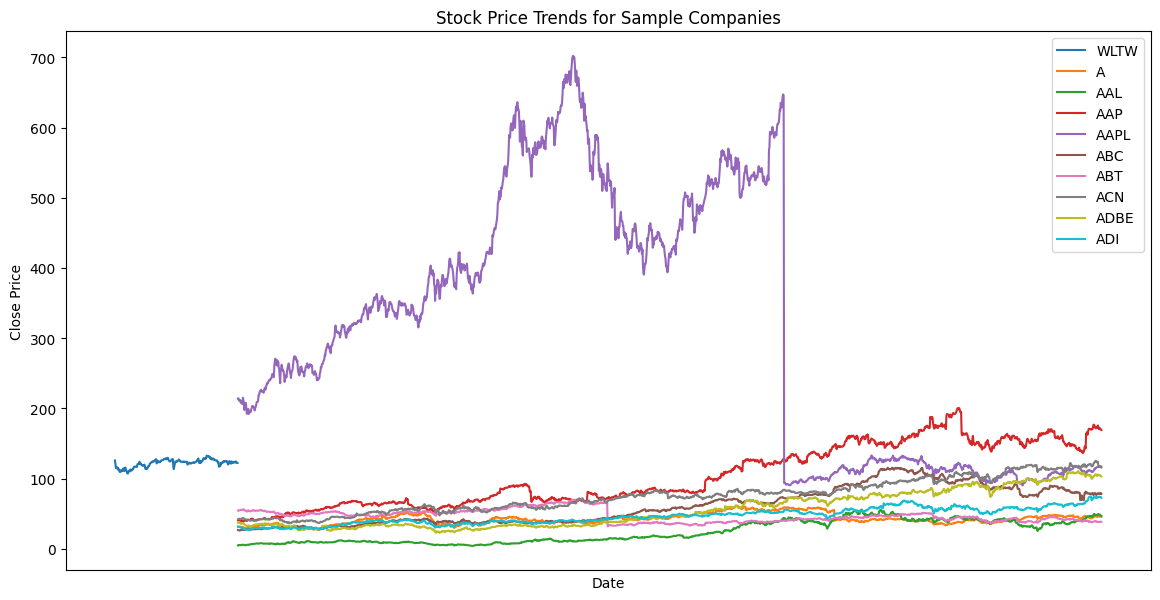

In [27]:

sample_symbols = prices['symbol'].unique()[:10]
sample_prices = prices[prices['symbol'].isin(sample_symbols)]

plt.figure(figsize=(14, 7))
for symbol in sample_symbols:
    plt.plot(sample_prices[sample_prices['symbol'] == symbol]['date'],
             sample_prices[sample_prices['symbol'] == symbol]['close'], label=symbol)
plt.legend()
plt.title('Stock Price Trends for Sample Companies')
plt.xlabel('Date')
plt.ylabel('Close Price')
plt.xticks([])
plt.xlabel('Date')
plt.show()


In [28]:
merged_data.columns

Index(['date', 'symbol', 'open', 'close', 'low', 'high', 'volume',
       'open_adjusted', 'close_adjusted', 'low_adjusted', 'high_adjusted',
       'volume_adjusted', 'Unnamed: 0', 'Ticker Symbol', 'Period Ending',
       'Accounts Payable', 'Accounts Receivable', 'Add'l income/expense items',
       'After Tax ROE', 'Capital Expenditures', 'Capital Surplus',
       'Cash Ratio', 'Cash and Cash Equivalents', 'Changes in Inventories',
       'Common Stocks', 'Cost of Revenue', 'Current Ratio',
       'Deferred Asset Charges', 'Deferred Liability Charges', 'Depreciation',
       'Earnings Before Interest and Tax', 'Earnings Before Tax',
       'Effect of Exchange Rate',
       'Equity Earnings/Loss Unconsolidated Subsidiary', 'Fixed Assets',
       'Goodwill', 'Gross Margin', 'Gross Profit', 'Income Tax',
       'Intangible Assets', 'Interest Expense', 'Inventory', 'Investments',
       'Liabilities', 'Long-Term Debt', 'Long-Term Investments',
       'Minority Interest', 'Misc. Stocks',

## Feature Engineering

In [29]:
# Define a function to calculate indicators for a dataset
def calculate_indicators(data):
    data['RSI'] = RSIIndicator(data['close']).rsi()
    data['MV20'] = data['close'].rolling(window=20).mean()
    data['MV50'] = data['close'].rolling(window=50).mean()
    data['MV100'] = data['close'].rolling(window=100).mean()
    data['MV200'] = data['close'].rolling(window=200).mean()

    macd = MACD(data['close'])
    data['MACD'] = macd.macd()
    data['MACD_signal'] = macd.macd_signal()
    data['MACD_diff'] = macd.macd_diff()

    adx = ADXIndicator(data['high'], data['low'], data['close'])
    data['ADX'] = adx.adx()
    data['ADX_pos'] = adx.adx_pos()
    data['ADX_neg'] = adx.adx_neg()

    indicator_bb = BollingerBands(close=data["close"], window=20, window_dev=2)
    data['bb_bbm'] = indicator_bb.bollinger_mavg()
    data['bb_bbh'] = indicator_bb.bollinger_hband()
    data['bb_bbl'] = indicator_bb.bollinger_lband()
    data['bb_bbw'] = indicator_bb.bollinger_wband()

    return data

# Separate the dataset by symbol
msft_data = msfb_df[msfb_df['symbol'] == 'MSFT']
fb_data = msfb_df[msfb_df['symbol'] == 'FB']

# Calculate indicators for each symbol separately
msft_data = calculate_indicators(msft_data)
fb_data = calculate_indicators(fb_data)

# Combine the processed datasets
msfb_ta = pd.concat([msft_data, fb_data])

<ipython-input-29-be7261b08faa>:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['RSI'] = RSIIndicator(data['close']).rsi()
<ipython-input-29-be7261b08faa>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['MV20'] = data['close'].rolling(window=20).mean()
<ipython-input-29-be7261b08faa>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org

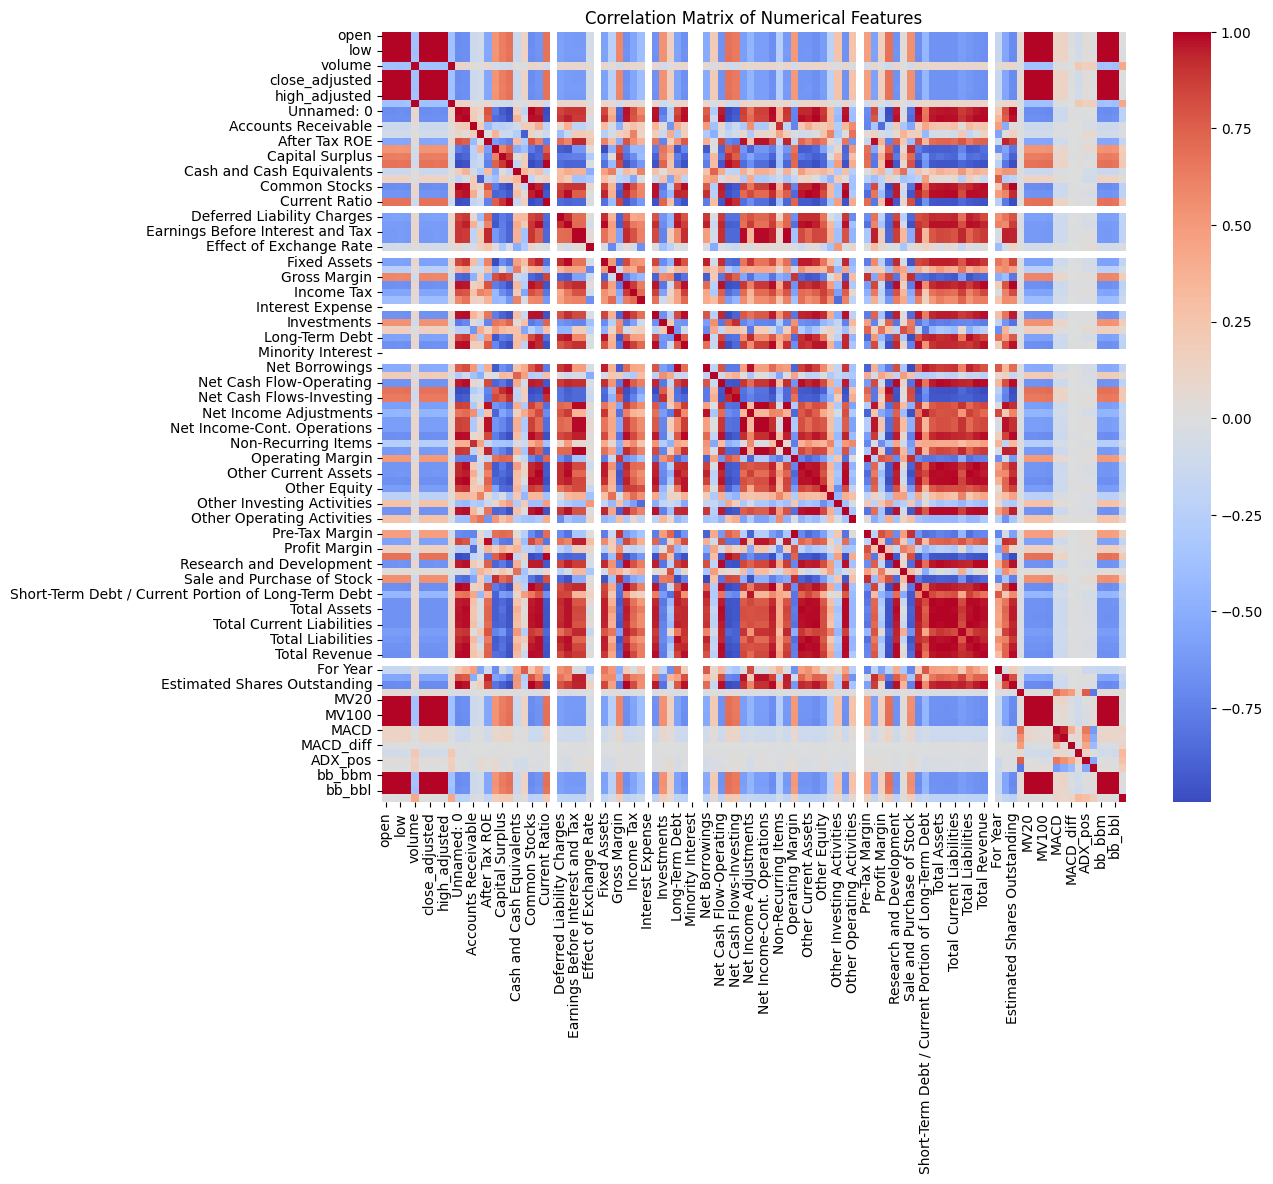

In [30]:
# Select only numerical features for correlation analysis
numerical_features = msfb_ta.select_dtypes(include=np.number)

# Calculate the correlation matrix
correlation_matrix = numerical_features.corr()

# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()


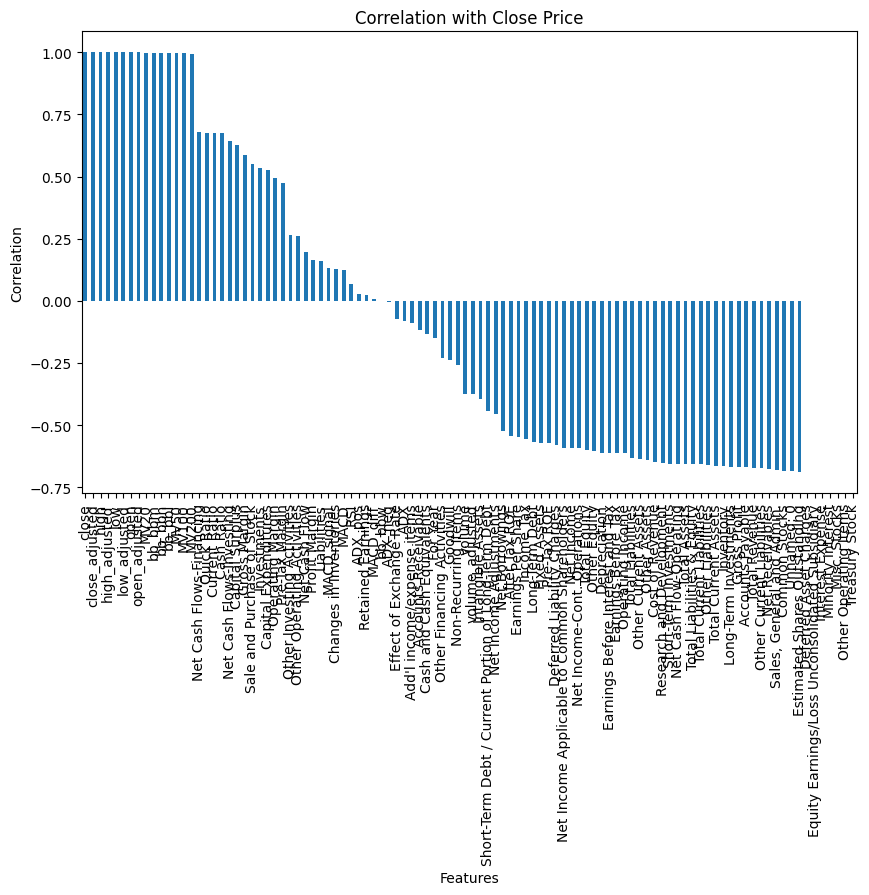

In [31]:
# Calculate the correlation of other features with the 'close' price
correlation_with_close = numerical_features.corr()['close'].sort_values(ascending=False)

# You can also visualize the correlation with a bar plot
plt.figure(figsize=(10, 6))
correlation_with_close.plot(kind='bar')
plt.title('Correlation with Close Price')
plt.xlabel('Features')
plt.ylabel('Correlation')
plt.xticks(rotation=90)
plt.show()


## Feature Selection

In [32]:
# Filter features with correlation less than 0.6 (positive or negative)
selected_features = correlation_with_close[(correlation_with_close < 0.75) & (correlation_with_close > -0.75)].index.tolist()

# Remove features that have no or very little correlation with 'close' price
selected_features = [feature for feature in selected_features if abs(correlation_with_close[feature]) > 0.1]

print("Selected features:", selected_features)


Selected features: ['Net Cash Flows-Financing', 'Quick Ratio', 'Current Ratio', 'Cash Ratio', 'Net Cash Flows-Investing', 'Capital Surplus', 'Gross Margin', 'Sale and Purchase of Stock', 'Investments', 'Capital Expenditures', 'Operating Margin', 'Pre-Tax Margin', 'Other Investing Activities', 'Other Operating Activities', 'Net Cash Flow', 'Profit Margin', 'Liabilities', 'MACD_signal', 'Changes in Inventories', 'MACD', 'Accounts Receivable', 'Cash and Cash Equivalents', 'For Year', 'Other Financing Activities', 'Goodwill', 'Non-Recurring Items', 'volume', 'volume_adjusted', 'Intangible Assets', 'Short-Term Debt / Current Portion of Long-Term Debt', 'Net Income Adjustments', 'Net Borrowings', 'After Tax ROE', 'Earnings Per Share', 'Income Tax', 'Long-Term Debt', 'Fixed Assets', 'Pre-Tax ROE', 'Deferred Liability Charges', 'Net Income Applicable to Common Shareholders', 'Net Income', 'Net Income-Cont. Operations', 'Total Equity', 'Other Equity', 'Depreciation', 'Earnings Before Interest a

In [33]:
# Create a new DataFrame 'microsoft' with selected columns for Microsoft data
msfb_ta = msfb_ta[['date', 'open', 'close', 'volume', 'symbol'] + selected_features]


In [34]:
msfb_ta.columns

Index(['date', 'open', 'close', 'volume', 'symbol', 'Net Cash Flows-Financing',
       'Quick Ratio', 'Current Ratio', 'Cash Ratio',
       'Net Cash Flows-Investing', 'Capital Surplus', 'Gross Margin',
       'Sale and Purchase of Stock', 'Investments', 'Capital Expenditures',
       'Operating Margin', 'Pre-Tax Margin', 'Other Investing Activities',
       'Other Operating Activities', 'Net Cash Flow', 'Profit Margin',
       'Liabilities', 'MACD_signal', 'Changes in Inventories', 'MACD',
       'Accounts Receivable', 'Cash and Cash Equivalents', 'For Year',
       'Other Financing Activities', 'Goodwill', 'Non-Recurring Items',
       'volume', 'volume_adjusted', 'Intangible Assets',
       'Short-Term Debt / Current Portion of Long-Term Debt',
       'Net Income Adjustments', 'Net Borrowings', 'After Tax ROE',
       'Earnings Per Share', 'Income Tax', 'Long-Term Debt', 'Fixed Assets',
       'Pre-Tax ROE', 'Deferred Liability Charges',
       'Net Income Applicable to Common Share

## Filling Missing Values with Mean

In [35]:
# Print columns with missing values
missing_cols = msfb_ta.columns[msfb_ta.isnull().any()].tolist()
msfb_ta[missing_cols]


,MACD_signal,MACD,For Year,Earnings Per Share,Estimated Shares Outstanding
1042,NaN,NaN,2013.0,2.61,8.376628e+09
1043,NaN,NaN,2014.0,2.66,8.298496e+09
1044,NaN,NaN,2015.0,1.49,8.183221e+09
1045,NaN,NaN,2016.0,2.12,7.923585e+09
2706,NaN,NaN,2013.0,2.61,8.376628e+09
...,...,...,...,...,...
3022986,-0.540523,-0.610577,NaN,NaN,NaN
3024752,-0.575035,-0.713084,2013.0,0.62,2.404839e+09
3024753,-0.617082,-0.785269,2014.0,1.12,2.611607e+09
3024754,-0.660240,-0.832875,2015.0,1.31,2.800763e+09


In [36]:
# Fill missing values in numerical columns with the mean
numerical_cols = msfb_ta.select_dtypes(include=np.number).columns
# Fill missing values in numerical columns with the mean for each column
for col in numerical_cols:
    msfb_ta[col] = msfb_ta[col].fillna(msfb_ta[col].mean())


# Label the categorical feature

In [37]:
from sklearn.preprocessing import LabelEncoder

# Initialize LabelEncoder
label_encoder = LabelEncoder()

# Fit and transform the 'symbol' column
msfb_ta['symbol'] = label_encoder.fit_transform(msfb_ta['symbol'])


# Model Training

In [38]:
# Separate features (X) and target variable (y)
X = msfb_ta.drop(['close', 'date', 'Unnamed: 0', 'volume'], axis=1)
y = msfb_ta['close']

# Split data into training and testing sets while maintaining equal representation of stocks
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=msfb_ta['symbol'], random_state=42)

## XGBOOST

## XGBoost Training

In [39]:
# Define the parameter grid for XGBoost
param_grid = {
    'n_estimators': [100, 200, 300, 500],
    'learning_rate': [0.01, 0.1, 0.2, 0.5],
}

# Create an XGBoost regressor
xgb_model = XGBRegressor()

# Create a GridSearchCV object
grid_search = GridSearchCV(estimator=xgb_model, param_grid=param_grid,
                           scoring='neg_mean_squared_error', cv=5, n_jobs=-1)

# Fit the model to the training data
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=XGBRegressor(base_score=None, booster=None,
                                    callbacks=None, colsample_bylevel=None,
                                    colsample_bynode=None,
                                    colsample_bytree=None, device=None,
                                    early_stopping_rounds=None,
                                    enable_categorical=False, eval_metric=None,
                                    feature_types=None, gamma=None,
                                    grow_policy=None, importance_type=None,
                                    interaction_constraints=None,
                                    learning_rate=None, m...
                                    max_cat_to_onehot=None, max_delta_step=None,
                                    max_depth=None, max_leaves=None,
                                    min_child_weight=None, missing=nan,
                                    monotone_constraints=None,
                                    multi_strategy=None, n_estimators=None,
                                    n_jobs=None, num_parallel_tree=None,
                                    random_state=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1, 0.2, 0.5],
                         'n_estimators': [100, 200, 300, 500]},
             scoring='neg_mean_squared_error')

In [40]:
# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Best parameters: {'learning_rate': 0.2, 'n_estimators': 500}
Best score: -0.2052169170053725


In [41]:
# Get the best XGBoost model from the grid search
best_xgb_model = grid_search.best_estimator_

# Make predictions on the test set
y_pred = best_xgb_model.predict(X_test)

## ERROR MATRIXS for XGBOOST

In [42]:
xg_mse = mean_squared_error(y_test, y_pred)
xg_rmse = np.sqrt(xg_mse)
xg_mae = mean_absolute_error(y_test, y_pred)
xg_r2 = r2_score(y_test, y_pred)

# Print the evaluation metrics
print(f"Mean Squared Error (MSE): {xg_mse}")
print(f"Root Mean Squared Error (RMSE): {xg_rmse}")
print(f"Mean Absolute Error (MAE): {xg_mae}")
print(f"R-squared (R2): {xg_r2}")

Mean Squared Error (MSE): 0.12758857570499543
Root Mean Squared Error (RMSE): 0.35719543068885334
Mean Absolute Error (MAE): 0.229026687369171
R-squared (R2): 0.9998499961970874


## Actual vs Predicted Plot

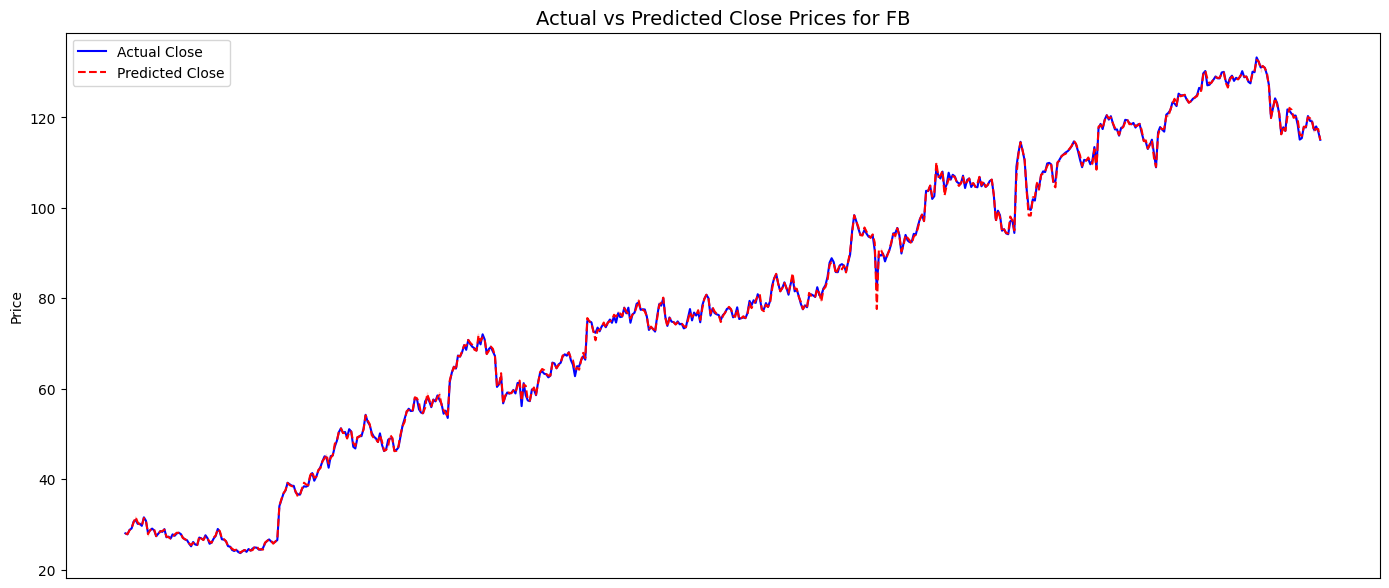

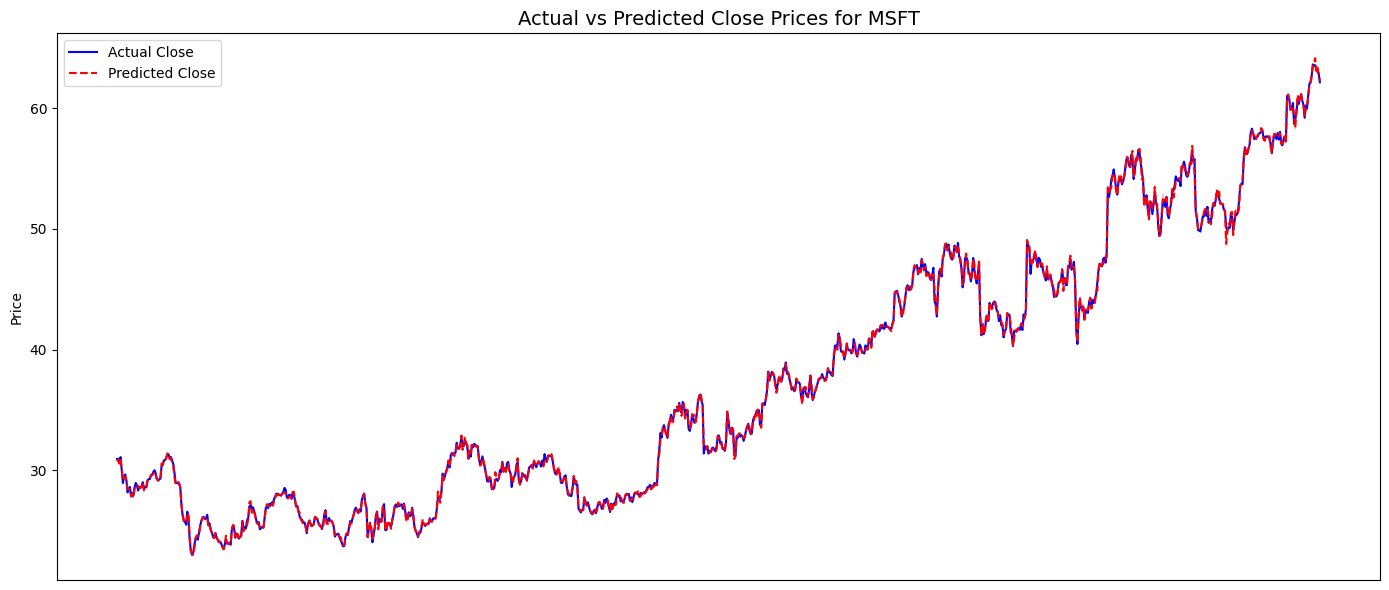

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

# Step 1: Recover original 'symbol' values for X_test
X_test_with_meta = X_test.copy()
X_test_with_meta['symbol'] = msfb_ta.loc[X_test.index, 'symbol']
X_test_with_meta['date'] = msfb_ta.loc[X_test.index, 'date']
y_test = y_test.to_numpy()
X_test_with_meta['Actual_Close'] = y_test
X_test_with_meta['Predicted_Close'] = y_pred

# Step 2: Inverse transform symbol labels back to original string names
X_test_with_meta['symbol_str'] = label_encoder.inverse_transform(X_test_with_meta['symbol'])

# Step 3: Plotting function
def plot_stock_predictions(data, stock_symbol):
    stock_data = data[data['symbol_str'] == stock_symbol].sort_values(by='date')

    plt.figure(figsize=(14, 6))
    sns.lineplot(data=stock_data, x='date', y='Actual_Close', label='Actual Close', color='blue')
    sns.lineplot(data=stock_data, x='date', y='Predicted_Close', label='Predicted Close', color='red', linestyle='--')
    plt.title(f'Actual vs Predicted Close Prices for {stock_symbol}', fontsize=14)
    plt.xlabel('Date')
    plt.ylabel('Price')
    plt.xticks(rotation=45)
    plt.legend()
    plt.grid(False)
    plt.gca().axes.get_xaxis().set_visible(False)
    plt.tight_layout()
    plt.show()

# Step 4: Plot for Facebook and Microsoft
plot_stock_predictions(X_test_with_meta, 'FB')
plot_stock_predictions(X_test_with_meta, 'MSFT')


## LSTM Model

## Scaling the Values

In [44]:
# First, sort the data by date
msfb_ta['date'] = pd.to_datetime(msfb_ta['date'])
msfb_ta.sort_values('date', inplace=True)

# Select relevant features (only numeric features needed for LSTM)
features = ['open', 'symbol', 'Net Cash Flows-Financing', 'Quick Ratio',
       'Current Ratio', 'Cash Ratio', 'Net Cash Flows-Investing',
       'Capital Surplus', 'Gross Margin', 'Sale and Purchase of Stock',
       'Investments', 'Capital Expenditures', 'Operating Margin',
       'Pre-Tax Margin', 'Other Investing Activities',
       'Other Operating Activities', 'Net Cash Flow', 'Profit Margin',
       'Liabilities', 'MACD_signal', 'Changes in Inventories', 'MACD',
       'Accounts Receivable', 'Cash and Cash Equivalents', 'For Year',
       'Other Financing Activities', 'Goodwill', 'Non-Recurring Items',
       'volume_adjusted', 'Intangible Assets',
       'Short-Term Debt / Current Portion of Long-Term Debt',
       'Net Income Adjustments', 'Net Borrowings', 'After Tax ROE',
       'Earnings Per Share', 'Income Tax', 'Long-Term Debt', 'Fixed Assets',
       'Pre-Tax ROE', 'Deferred Liability Charges',
       'Net Income Applicable to Common Shareholders', 'Net Income',
       'Net Income-Cont. Operations', 'Total Equity', 'Other Equity',
       'Depreciation', 'Earnings Before Interest and Tax',
       'Earnings Before Tax', 'Operating Income', 'Total Liabilities',
       'Other Current Assets', 'Other Assets', 'Cost of Revenue',
       'Research and Development', 'Short-Term Investments',
       'Net Cash Flow-Operating', 'Total Assets', 'Total Liabilities & Equity',
       'Total Current Liabilities', 'Other Liabilities',
       'Total Current Assets', 'Inventory', 'Long-Term Investments',
       'Gross Profit', 'Accounts Payable', 'Total Revenue',
       'Other Current Liabilities', 'Net Receivables',
       'Sales, General and Admin.', 'Common Stocks',
       'Estimated Shares Outstanding']
target = ['close']

# Use MinMaxScaler to normalize the data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(msfb_ta[features + target])

In [45]:
# Create sequences (X, y)
def create_sequences(data, time_step=1):
    X = []
    y = []
    for i in range(time_step, len(data)):
        X.append(data[i-time_step:i, :-1])  # All features (except target)
        y.append(data[i, -1])  # Target (close price)
    return np.array(X), np.array(y)


## Set the Parameter for Lstm

In [46]:


# Initialize variables to track the best model
best_model = None
best_time_step = None
best_val_loss = float('inf')
best_params = {}

# Define hyperparameter values to test
time_steps = [2, 4, 5, 10]
learning_rates = [0.0001, 0.001, 0.01]
units_list = [50, 100, 200]
batch_sizes = [32]
epochs_list = [20]


## LSTM Training

In [47]:
# Initialize best validation loss
best_val_loss = float('inf')

# Loop through the time_steps and hyperparameters to handle data processing and training
for time_step in time_steps:
    # Create sequences for each time_step
    X, y = create_sequences(scaled_data, time_step=time_step)

    # Split the data for each time_step
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

    # Reshape the data for LSTM input (3D: samples, time_step, features) for each time_step
    X_train = X_train.reshape((X_train.shape[0], X_train.shape[1], X_train.shape[2]))
    X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))

    # Loop through hyperparameters
    for lr in learning_rates:
        for units in units_list:
            for batch_size in batch_sizes:
                for epochs in epochs_list:
                    # Build and compile the model
                    model = Sequential()
                    model.add(LSTM(units=units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
                    model.add(LSTM(units=units, return_sequences=False))
                    model.add(Dense(units=1))  # Output layer for predicting the close price

                    # Compile the model using Adam optimizer and loss function
                    model.compile(optimizer=Adam(learning_rate=lr), loss='mean_squared_error')

                    # Define EarlyStopping callback
                    early_stopping = EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1)

                    # Train the model with early stopping
                    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_data=(X_test, y_test),
                                        verbose=1, callbacks=[early_stopping])

                    # Track the best model based on validation loss
                    val_loss = history.history['val_loss'][-1]  # Get the final validation loss

                    if val_loss < best_val_loss:
                        best_val_loss = val_loss
                        best_model = model
                        best_time_step = time_step
                        best_params = {
                            'learning_rate': lr,
                            'units': units,
                            'batch_size': batch_size,
                            'epochs': epochs
                        }
                        best_history = history


Epoch 1/20


/usr/local/lib/python3.11/dist-packages/keras/src/layers/rnn/rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


277/277 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.0406 - val_loss: 0.1860
Epoch 2/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0255 - val_loss: 0.1500
Epoch 3/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0208 - val_loss: 0.1025
Epoch 4/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 0.0146 - val_loss: 0.0887
Epoch 5/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0130 - val_loss: 0.0797
Epoch 6/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.0123 - val_loss: 0.0795
Epoch 7/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0120 - val_loss: 0.0774
Epoch 8/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0115 - val_loss: 0.0760
Epoch 9/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.0114 - val_loss: 0.0757
Epoch 10/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0118 - val_loss: 0.0737
Epoch 11/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 0.0110 - val_loss: 0.0748
Epoch 12/20
277/277 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 0.

## Print the best Model

In [48]:
# Print the best model's summary
print(f"Best Model (Time Step {best_time_step}):")
best_model.summary()

# Create sequences for each time_step
X, y = create_sequences(scaled_data, time_step=5)

# Split the data for each time_step
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Reshape the data for LSTM input (3D: samples, time_step, features) for each time_step
X_test = X_test.reshape((X_test.shape[0], X_test.shape[1], X_test.shape[2]))


# Evaluate the best model on the test data
test_loss = best_model.evaluate(X_test, y_test)
print(f"\nTest Loss: {test_loss}")



Best Model (Time Step 4):


Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                  │ (None, 4, 200)         │       217,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_29 (LSTM)                  │ (None, 200)            │       320,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 1)              │           201 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,615,805 (6.16 MB)

 Trainable params: 538,601 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 1,077,204 (4.11 MB)

70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0517

Test Loss: 0.06216486543416977


In [49]:
# Print the best hyperparameters
print(f"\nBest Hyperparameters: {best_params}")


Best Hyperparameters: {'learning_rate': 0.001, 'units': 200, 'batch_size': 32, 'epochs': 20}


## Evaluation Matrixs of Lstm

In [50]:
import math

# Make predictions using the best model
predicted_prices = best_model.predict(X_test)

# Calculate additional error metrics directly on the scaled data
lstm_mae = mean_absolute_error(y_test, predicted_prices)
lstm_mse = mean_squared_error(y_test, predicted_prices)
lstm_rmse = math.sqrt(lstm_mse)
lstm_r2 = r2_score(y_test, predicted_prices)

print(f"\nMean Absolute Error (MAE): {lstm_mae}")
print(f"Mean Squared Error (MSE): {lstm_mse}")
print(f"Root Mean Squared Error (RMSE): {lstm_rmse}")
print(f"R² (Coefficient of Determination): {lstm_r2}")


70/70 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step

Mean Absolute Error (MAE): 0.20184325226585945
Mean Squared Error (MSE): 0.062164867888542155
Root Mean Squared Error (RMSE): 0.24932883485177193
R² (Coefficient of Determination): 0.21945110696319314


# Visualize the predicted vs Actual values plot

In [51]:
# Use the same scaler and features
X_all, y_all = create_sequences(scaled_data, time_step=5)

# Split again (no shuffle to preserve the order)
X_train, X_test, y_train, y_test = train_test_split(X_all, y_all, test_size=0.2, shuffle=False)

# Recover the test start index relative to msfb_ta
test_start_index = len(X_all) - len(X_test)

# Now we can get the original indices of test targets
test_indices = list(range(test_start_index + 5, test_start_index + 5 + len(y_test)))  # +5 because sequences shift by time_step

# Extract date and symbol from original DataFrame
dates = msfb_ta.iloc[test_indices]['date'].values
symbols = msfb_ta.iloc[test_indices]['symbol'].values


In [52]:
# Flatten predictions
predicted_flat = predicted_prices.flatten()
y_test_flat = y_test.flatten()

# Build final DataFrame
X_lstm_test_with_meta = pd.DataFrame({
    'date': dates,
    'symbol': symbols,
    'Actual_Close': y_test_flat,
    'Predicted_Close': predicted_flat
})

# Decode symbol if needed
X_lstm_test_with_meta['symbol_str'] = label_encoder.inverse_transform(X_lstm_test_with_meta['symbol'])

# Sort for plotting
X_lstm_test_with_meta.sort_values(by='date', inplace=True)


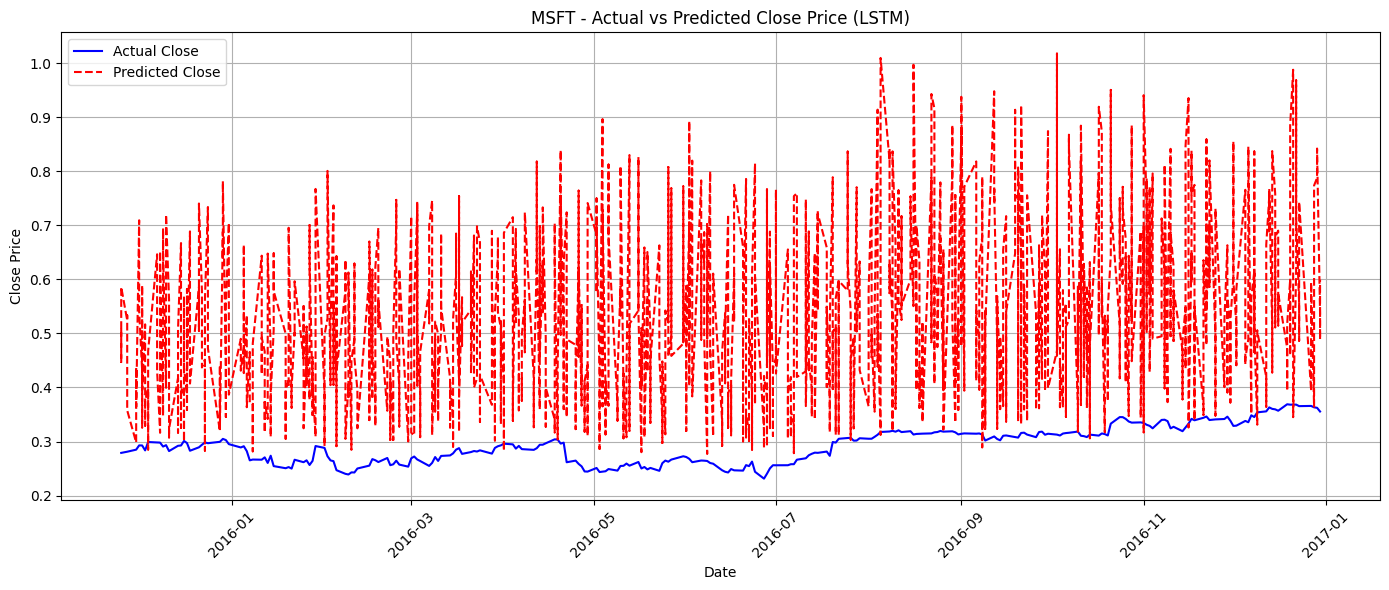

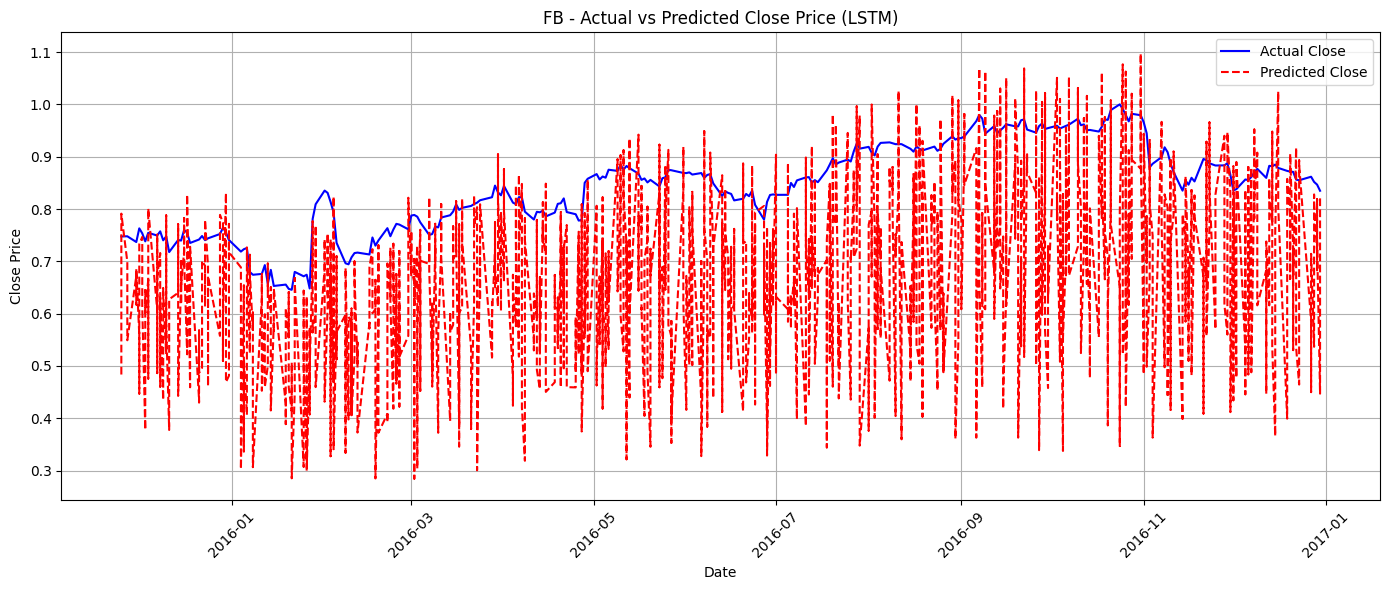

In [53]:
def plot_predictions(df, symbol):
    stock_df = df[df['symbol_str'] == symbol]
    plt.figure(figsize=(14, 6))
    plt.plot(stock_df['date'], stock_df['Actual_Close'], label='Actual Close', color='blue')
    plt.plot(stock_df['date'], stock_df['Predicted_Close'], label='Predicted Close', color='red', linestyle='--')
    plt.title(f'{symbol} - Actual vs Predicted Close Price (LSTM)')
    plt.xlabel('Date')
    plt.ylabel('Close Price')
    plt.legend()
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


plot_predictions(X_lstm_test_with_meta, 'MSFT')
plot_predictions(X_lstm_test_with_meta, 'FB')


# Random Forest

In [54]:
# Convert date column to datetime and sort
msfb_ta['date'] = pd.to_datetime(msfb_ta['date'])
msfb_ta.sort_values('date', inplace=True)

# Select relevant features
features = ['open', 'symbol', 'Net Cash Flows-Financing', 'Quick Ratio',
       'Current Ratio', 'Cash Ratio', 'Net Cash Flows-Investing',
       'Capital Surplus', 'Gross Margin', 'Sale and Purchase of Stock',
       'Investments', 'Capital Expenditures', 'Operating Margin',
       'Pre-Tax Margin', 'Other Investing Activities',
       'Other Operating Activities', 'Net Cash Flow', 'Profit Margin',
       'Liabilities', 'MACD_signal', 'Changes in Inventories', 'MACD',
       'Accounts Receivable', 'Cash and Cash Equivalents', 'For Year',
       'Other Financing Activities', 'Goodwill', 'Non-Recurring Items',
       'volume_adjusted', 'Intangible Assets',
       'Short-Term Debt / Current Portion of Long-Term Debt',
       'Net Income Adjustments', 'Net Borrowings', 'After Tax ROE',
       'Earnings Per Share', 'Income Tax', 'Long-Term Debt', 'Fixed Assets',
       'Pre-Tax ROE', 'Deferred Liability Charges',
       'Net Income Applicable to Common Shareholders', 'Net Income',
       'Net Income-Cont. Operations', 'Total Equity', 'Other Equity',
       'Depreciation', 'Earnings Before Interest and Tax',
       'Earnings Before Tax', 'Operating Income', 'Total Liabilities',
       'Other Current Assets', 'Other Assets', 'Cost of Revenue',
       'Research and Development', 'Short-Term Investments',
       'Net Cash Flow-Operating', 'Total Assets', 'Total Liabilities & Equity',
       'Total Current Liabilities', 'Other Liabilities',
       'Total Current Assets', 'Inventory', 'Long-Term Investments',
       'Gross Profit', 'Accounts Payable', 'Total Revenue',
       'Other Current Liabilities', 'Net Receivables',
       'Sales, General and Admin.', 'Common Stocks',
       'Estimated Shares Outstanding']
target = ['close']

# Normalize data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(msfb_ta[features + target])


In [55]:
# scaled_data includes both features + target (close)
scaled_df = pd.DataFrame(scaled_data, columns=features + target)

# Sort by date first to maintain temporal order
msfb_ta = msfb_ta.sort_values('date').reset_index(drop=True)
scaled_df = scaled_df.reset_index(drop=True)

In [56]:
# Separate features (X) and target variable (y)
X = scaled_df.drop(['close'], axis=1)
y = scaled_df['close']

# Split data into training and testing sets while maintaining equal representation of stocks
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=msfb_ta['symbol'], random_state=42)


# Define the Random Forest model
rf_model = RandomForestRegressor(random_state=42)

# Define the hyperparameter grid
param_grid = {
    'n_estimators': [50, 100, 200, 500],
    'max_depth': [10, 20, 30, None],
    'max_features': ['sqrt', 'log2']
}

## RF Training

In [57]:
# Define model
rf = RandomForestRegressor(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_grid,
    n_iter=20,
    cv=3,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

# Fit model
random_search.fit(X_train, y_train)

Fitting 3 folds for each of 20 candidates, totalling 60 fits


RandomizedSearchCV(cv=3, estimator=RandomForestRegressor(random_state=42),
                   n_iter=20, n_jobs=-1,
                   param_distributions={'max_depth': [10, 20, 30, None],
                                        'max_features': ['sqrt', 'log2'],
                                        'n_estimators': [50, 100, 200, 500]},
                   random_state=42, verbose=2)

## Error Matrixs

In [61]:
# Best model
best_rf_model = random_search.best_estimator_

# Make predictions
y_pred = best_rf_model.predict(X_test)

# Evaluate performance
rf_mae = mean_absolute_error(y_test, y_pred)
rf_mse = mean_squared_error(y_test, y_pred)
rf_rmse = np.sqrt(rf_mse)
rf_r2 = r2_score(y_test, y_pred)

# Print results
print(f"Best Hyperparameters: {random_search.best_params_}")
print(f"\nError Metrics:")
print(f"Mean Absolute Error (MAE): {rf_mae:.6f}")
print(f"Mean Squared Error (MSE): {rf_mse:.6f}")
print(f"Root Mean Squared Error (RMSE): {rf_rmse:.6f}")
print(f"R² Score: {rf_r2:.6f}")


Best Hyperparameters: {'n_estimators': 50, 'max_features': 'sqrt', 'max_depth': 30}

Error Metrics:
Mean Absolute Error (MAE): 0.014784
Mean Squared Error (MSE): 0.000595
Root Mean Squared Error (RMSE): 0.024395
R² Score: 0.991233


## Actual vs Predicted Plot

In [64]:
results_df

,date,symbol,actual_close,predicted_close
1094,2011-02-02,MSFT,0.045660,0.051785
1678,2011-08-31,MSFT,0.033521,0.043751
520,2010-07-12,MSFT,0.017485,0.022665
1481,2011-06-22,MSFT,0.015854,0.027913
10928,2016-12-05,MSFT,0.856405,0.839491
...,...,...,...,...
8925,2015-12-07,MSFT,0.749321,0.812328
3957,2013-06-20,FB,0.095941,0.092162
3529,2013-04-05,MSFT,0.052546,0.046816
1988,2011-12-21,MSFT,0.025910,0.027456


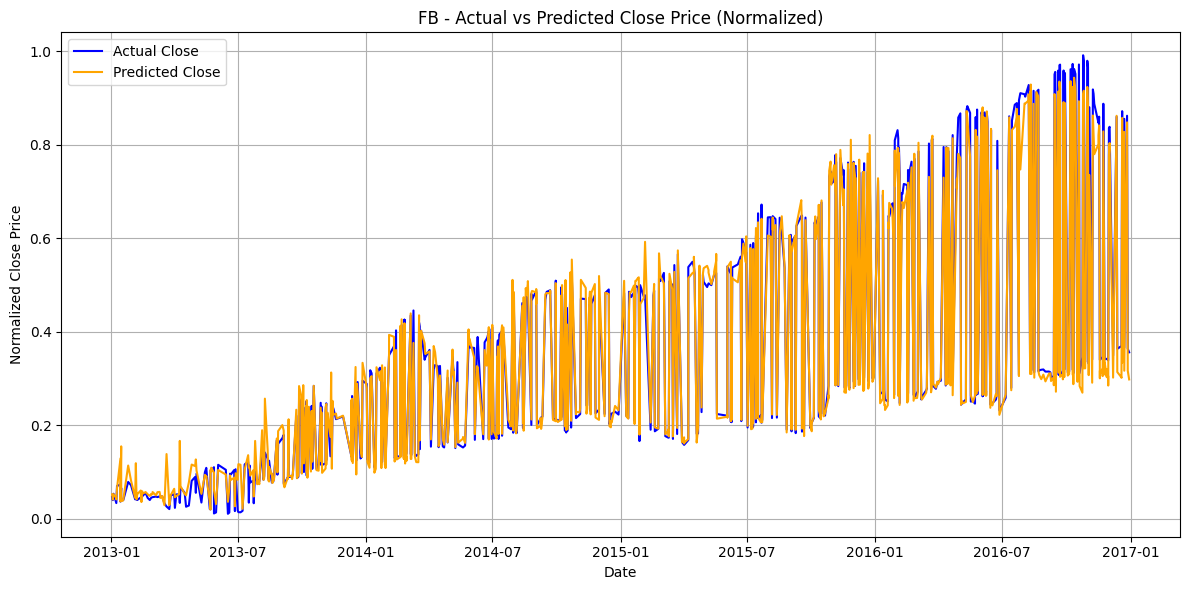

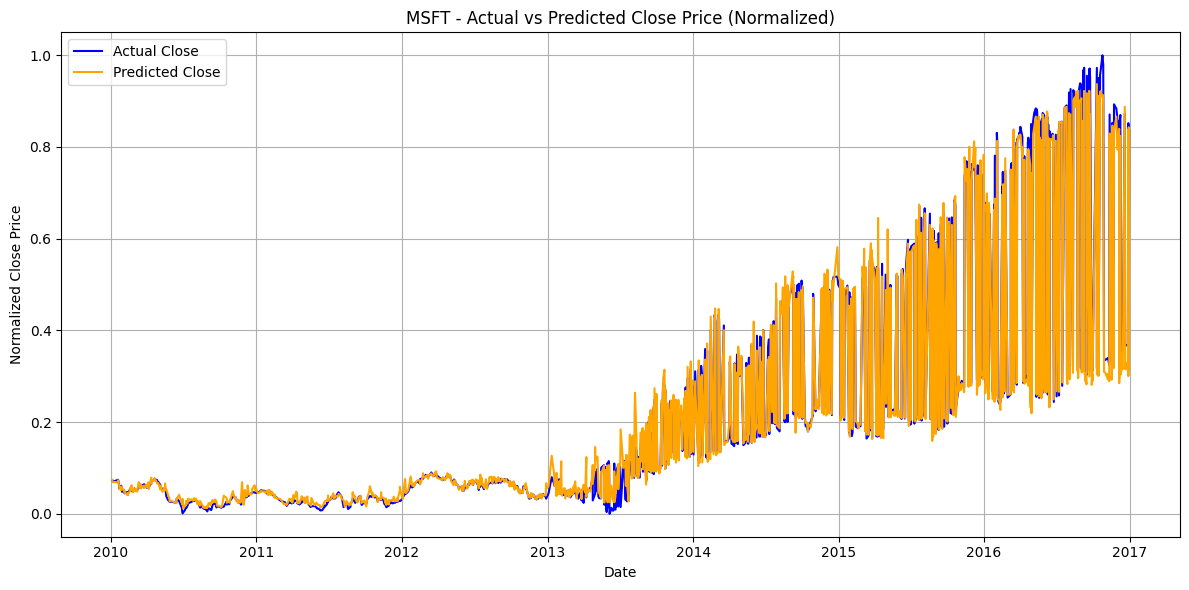

In [63]:
# Save the mapping for later use
symbol_mapping = dict(zip(label_encoder.transform(label_encoder.classes_), label_encoder.classes_))


# Create results DataFrame for plotting
test_indices = X_test.index
results_df = msfb_ta.loc[test_indices, ['date', 'symbol']].copy()
results_df['actual_close'] = y_test
results_df['predicted_close'] = y_pred

# Decode symbol column
results_df['symbol'] = results_df['symbol'].map(symbol_mapping)

# Plotting actual vs predicted for FB and MSFT
for symbol in ['FB', 'MSFT']:
    df_plot = results_df[results_df['symbol'] == symbol].sort_values('date')

    plt.figure(figsize=(12, 6))
    plt.plot(df_plot['date'], df_plot['actual_close'], label='Actual Close', color='blue')
    plt.plot(df_plot['date'], df_plot['predicted_close'], label='Predicted Close', color='orange')
    plt.title(f'{symbol} - Actual vs Predicted Close Price (Normalized)')
    plt.xlabel('Date')
    plt.ylabel('Normalized Close Price')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

## Comparision of the Three Models Evaluation Matrixs

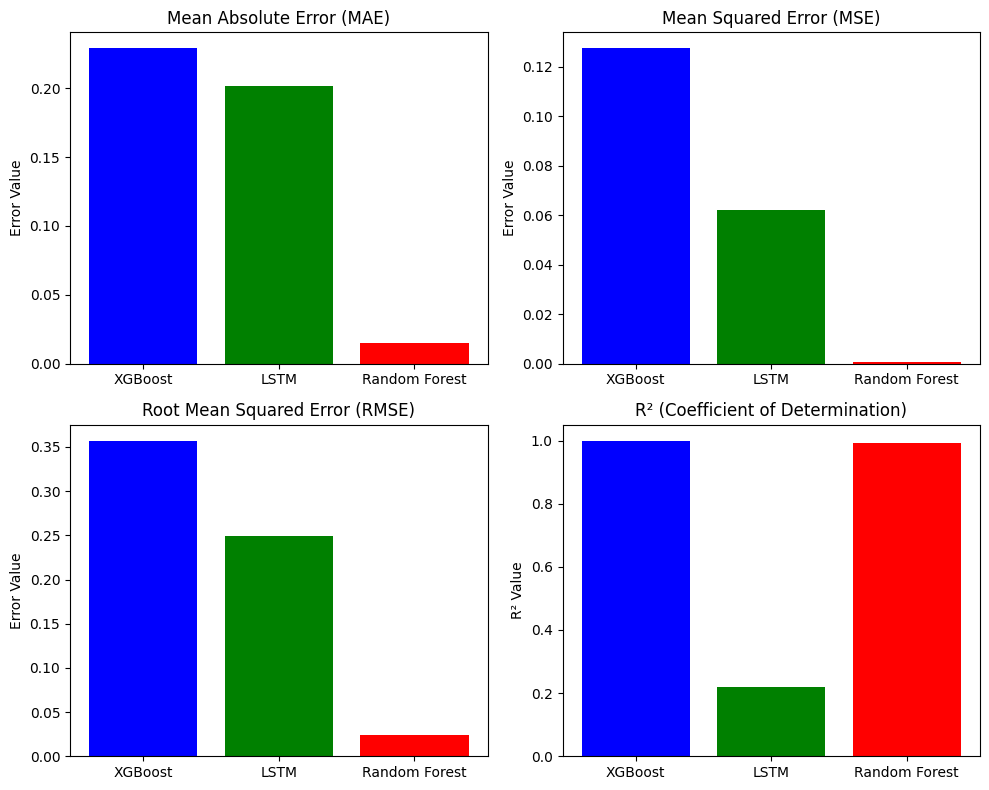

In [65]:
# Plotting the error metrics
models = ['XGBoost', 'LSTM', 'Random Forest']
mae = [xg_mae, lstm_mae, rf_mae]
mse = [xg_mse, lstm_mse, rf_mse]
rmse = [xg_rmse, lstm_rmse, rf_rmse]
r2 = [xg_r2, lstm_r2, rf_r2]

fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# Plot MAE
ax[0, 0].bar(models, mae, color=['blue', 'green', 'red'])
ax[0, 0].set_title('Mean Absolute Error (MAE)')
ax[0, 0].set_ylabel('Error Value')

# Plot MSE
ax[0, 1].bar(models, mse, color=['blue', 'green', 'red'])
ax[0, 1].set_title('Mean Squared Error (MSE)')
ax[0, 1].set_ylabel('Error Value')

# Plot RMSE
ax[1, 0].bar(models, rmse, color=['blue', 'green', 'red'])
ax[1, 0].set_title('Root Mean Squared Error (RMSE)')
ax[1, 0].set_ylabel('Error Value')

# Plot R²
ax[1, 1].bar(models, r2, color=['blue', 'green', 'red'])
ax[1, 1].set_title('R² (Coefficient of Determination)')
ax[1, 1].set_ylabel('R² Value')

plt.tight_layout()
plt.show()